
# Manajemen Layanan Pelanggan dengan AI

**Deskripsi Proyek:**  
Pelayanan pelanggan yang buruk dapat merugikan reputasi dan kesuksesan bisnis. Dengan menggunakan AI, UMKM dapat menganalisis data interaksi pelanggan dan mengidentifikasi area layanan yang perlu diperbaiki. AI dapat membantu mendeteksi masalah yang sering dikeluhkan oleh pelanggan, memberikan wawasan untuk memperbaiki pengalaman pelanggan, serta meningkatkan tingkat retensi dan kepuasan pelanggan.  



## Langkah 1: Memuat Dataset

Langkah pertama adalah memuat data interaksi pelanggan yang mencakup informasi seperti waktu interaksi, keluhan, dan penilaian layanan. Dataset ini adalah data dummy yang digunakan untuk ilustrasi.


In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('24_manajemen_layanan_pelanggan.xlsx')
df

,Tanggal,Keluhan,Rating
0,2024-08-22,Produk rusak,5
1,2024-07-14,Puas,1
2,2024-10-13,Respon buruk,1
3,2024-02-25,Puas,5
4,2024-07-15,Respon buruk,3
...,...,...,...
295,2024-03-27,Pengiriman lambat,3
296,2024-06-19,Puas,4
297,2024-09-09,Produk rusak,4
298,2024-10-09,Layanan lambat,2



## Langkah 2: Visualisasi Data

Melakukan visualisasi untuk memahami pola umum keluhan dan distribusi rating pelanggan.


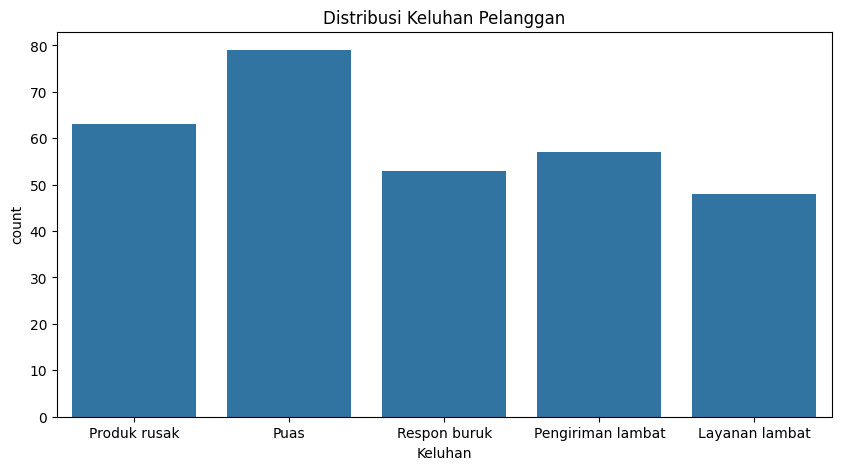

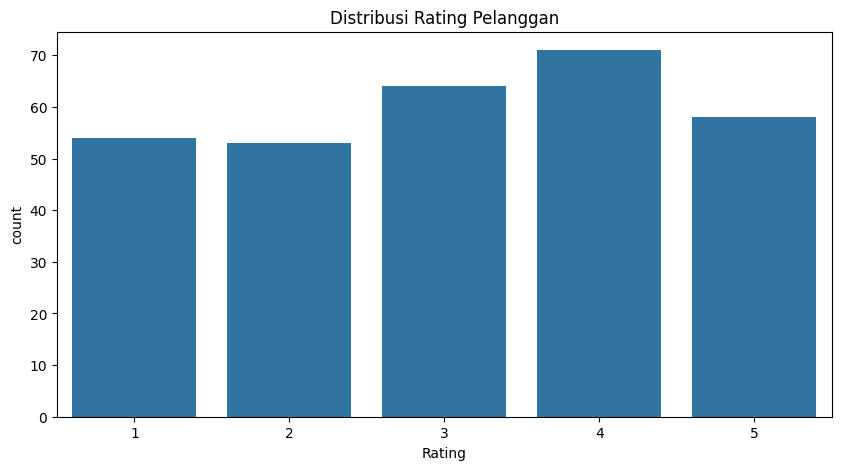

In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Keluhan')
plt.title('Distribusi Keluhan Pelanggan')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Rating')
plt.title('Distribusi Rating Pelanggan')
plt.show()



## Langkah 3: Preprocessing Data

Membersihkan data dan mengubah keluhan menjadi format numerik agar bisa digunakan untuk pelatihan model.


In [3]:

from sklearn.preprocessing import LabelEncoder

# Mengkodekan keluhan menjadi numerik
label_encoder = LabelEncoder()
df['Keluhan_encoded'] = label_encoder.fit_transform(df['Keluhan'])

print("Contoh data setelah encoding:")
print(df.head())


Contoh data setelah encoding:
     Tanggal       Keluhan  Rating  Keluhan_encoded
0 2024-08-22  Produk rusak       5                2
1 2024-07-14          Puas       1                3
2 2024-10-13  Respon buruk       1                4
3 2024-02-25          Puas       5                3
4 2024-07-15  Respon buruk       3                4



## Langkah 4: Normalisasi Data

Melakukan normalisasi data agar model machine learning bisa bekerja lebih baik.


In [4]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Rating', 'Keluhan_encoded']] = scaler.fit_transform(df[['Rating', 'Keluhan_encoded']])

print("Contoh data setelah normalisasi:")
print(df.head())


Contoh data setelah normalisasi:
     Tanggal       Keluhan  Rating  Keluhan_encoded
0 2024-08-22  Produk rusak     1.0             0.50
1 2024-07-14          Puas     0.0             0.75
2 2024-10-13  Respon buruk     0.0             1.00
3 2024-02-25          Puas     1.0             0.75
4 2024-07-15  Respon buruk     0.5             1.00



## Langkah 5: Membagi Data Train dan Test

Memisahkan data menjadi set pelatihan dan pengujian untuk evaluasi model.


In [5]:

from sklearn.model_selection import train_test_split

X = df[['Rating', 'Keluhan_encoded']]
y = (df['Keluhan'] != 'Puas').astype(int)  # 1 jika keluhan, 0 jika puas

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test:", X_test.shape[0])


Jumlah data train: 210
Jumlah data test: 90



## Langkah 6: Melatih Model

Menggunakan model Random Forest untuk memprediksi apakah pelanggan puas atau memiliki keluhan.


In [6]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model telah dilatih.")


Model telah dilatih.



## Langkah 7: Evaluasi Model

Mengukur akurasi model untuk melihat seberapa baik performanya.


In [7]:

from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Akurasi model:", accuracy_score(y_test, y_pred))
print("Laporan klasifikasi:")
print(classification_report(y_test, y_pred))


Akurasi model: 1.0
Laporan klasifikasi:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        62

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90




## Langkah 8: Prediksi

Melakukan prediksi apakah seorang pelanggan akan memberikan keluhan atau tidak.


In [8]:

# Contoh prediksi
sample = pd.DataFrame({'Rating': [0.8], 'Keluhan_encoded': [0.5]})
prediksi = model.predict(sample)

hasil = "Keluhan" if prediksi[0] == 1 else "Puas"
print(f"Hasil prediksi: {hasil}")


Hasil prediksi: Keluhan



## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
